In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_path = "/content/drive/MyDrive/Fraud-Detection-Project"
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Fraud-Detection-Project


In [3]:
!pip install shap

In [4]:
import pandas as pd
import numpy as np
import shap
import joblib

from sklearn.model_selection import train_test_split

In [5]:
model = joblib.load("models/tuned_xgboost.pkl")

In [6]:
df = pd.read_csv("data/Base.csv")

X = df.drop(columns=["fraud_bool"])
y = df["fraud_bool"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
xgb_model = model.named_steps["classifier"]
preprocessor = model.named_steps["preprocessor"]

In [8]:
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

In [9]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_transformed)

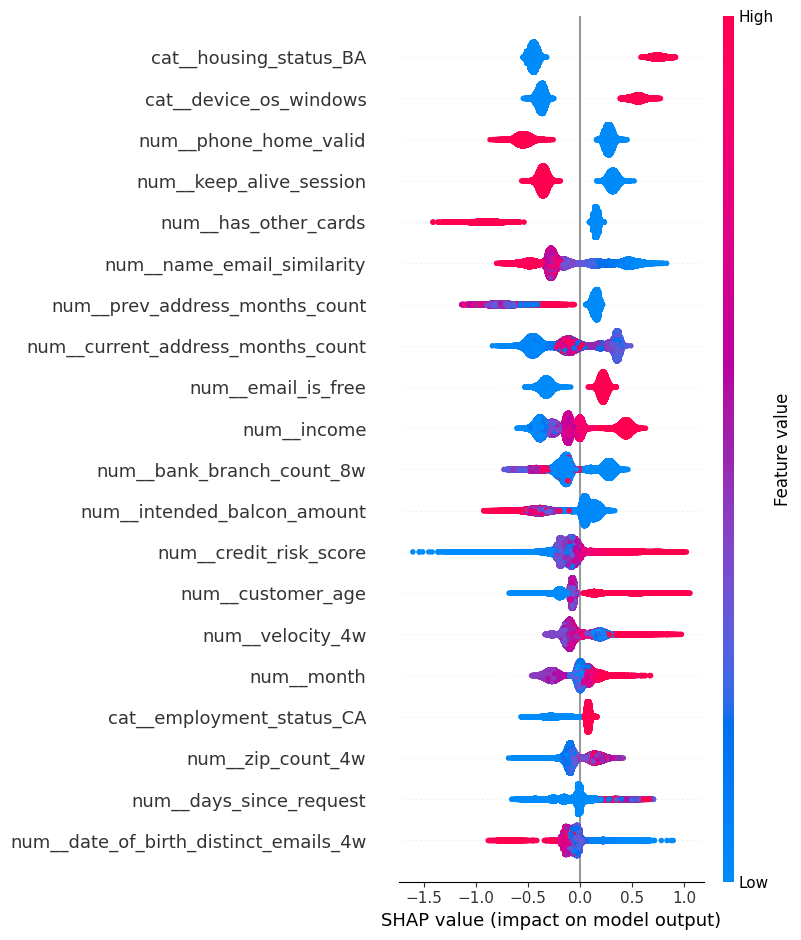

In [10]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

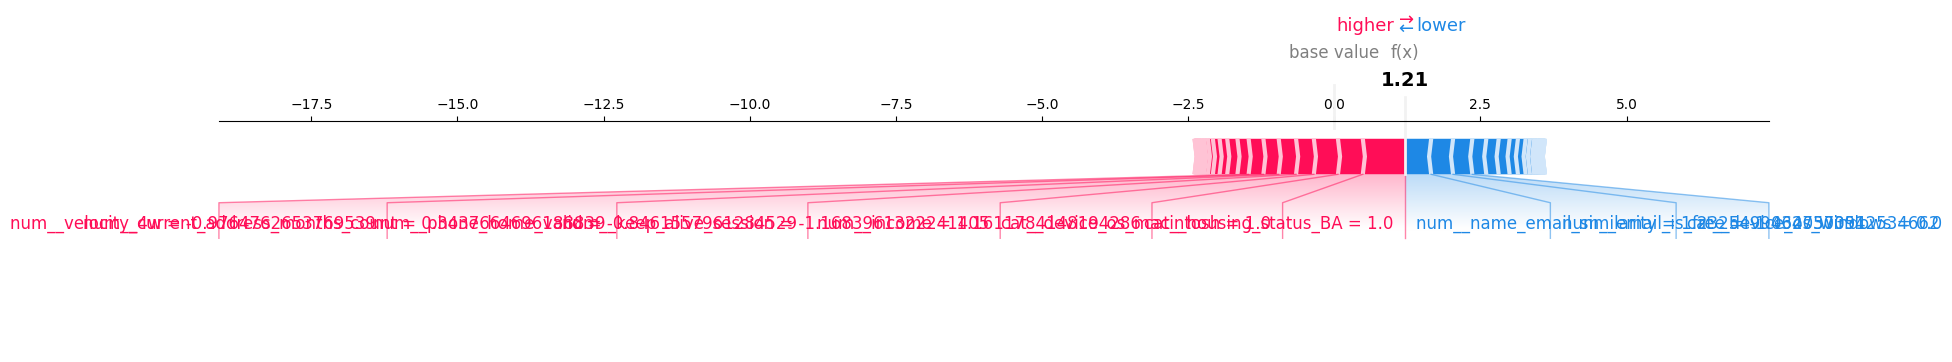

In [11]:
fraud_index = np.where(y_test == 1)[0][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_index],
    X_test_transformed[fraud_index],
    feature_names=feature_names,
    matplotlib=True
)